In [1]:

from data.movie import Frames, Audio

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import quantities as pq
import neo
from elephant.gpfa import GPFA
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

import torch
from torchvision import models, transforms
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image

## RAW Data

In [2]:
# Movie
fr = Frames()
l2 = fr.measures.l2.rescale(1.0)

au = Audio()
tim = au.instruments.timbre
vol = au.instruments.volume


# Spikes
raw = pd.read_parquet('raw_spikes.parquet')
spk = list(raw[raw.subj=="CS58"].enc_spikes.values)

100%|██████████| 144/144 [00:00<00:00, 258.70it/s]


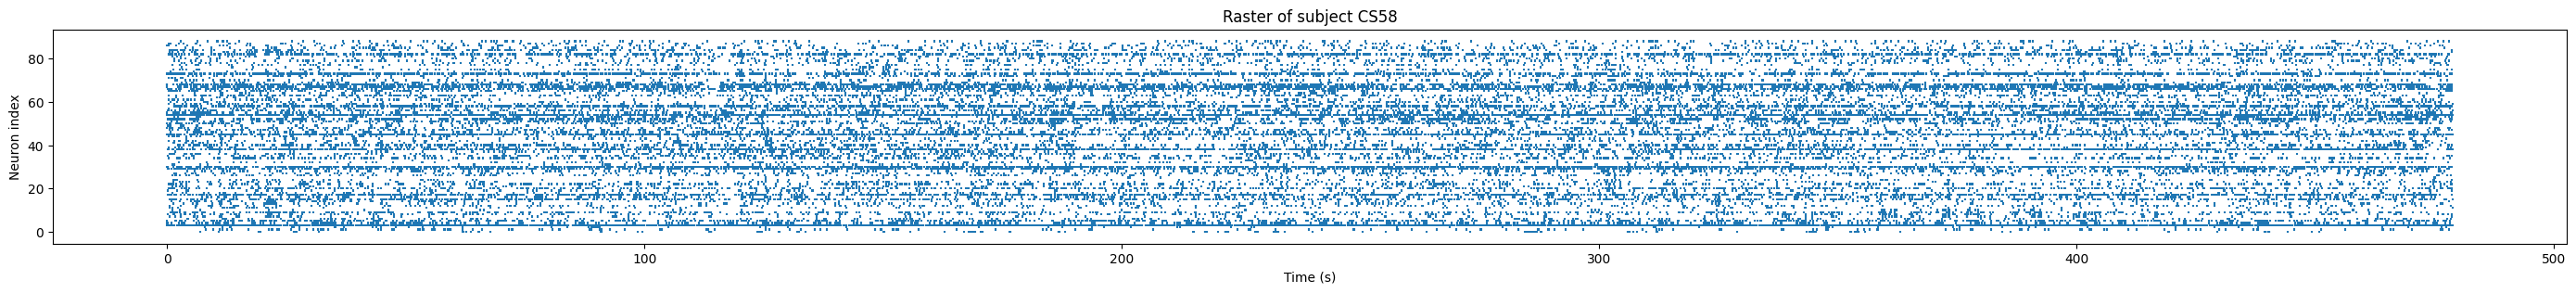

In [3]:
plt.figure(figsize=(35, 3))
plt.eventplot(spk, orientation='horizontal')
plt.xlabel('Time (s)')
plt.ylabel('Neuron index')
plt.title('Raster of subject CS58')
plt.show()

## Dim reduction

### Stimulus


#### Frame embedding

In [4]:
# 1) Load pretrained AlexNet and grab the fc7 features
alexnet = models.alexnet(weights="AlexNet_Weights.DEFAULT").eval()
return_nodes = {'classifier.5': 'fc7'}
fe = create_feature_extractor(alexnet, return_nodes)

# 2) ImageNet‐style preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),             # shorter edge → 256 px
    transforms.CenterCrop(224),         # → 224×224
    transforms.ToTensor(),              # → [0,1] C×H×W
    transforms.Normalize(               # ImageNet mean/std
      mean=[0.485, 0.456, 0.406],
      std=[0.229, 0.224, 0.225]
    ),
])

def embed_frames(frames: np.ndarray) -> np.ndarray:
    """
    frames: np.ndarray of shape (T, H, W), grayscale [0–255]
    returns: np.ndarray of shape (T, 4096)
    """
    T = frames.shape[0]
    embeds = np.zeros((T, 4096), dtype=np.float32)
    for t in tqdm(range(T)):
        # 1) convert to PIL RGB
        img = Image.fromarray(frames[t].astype(np.uint8)).convert('RGB')
        # 2) preprocess & batch
        x = preprocess(img).unsqueeze(0)           # 1×3×224×224
        # 3) forward‐pass
        with torch.no_grad():
            out = fe(x)['fc7']                    # 1×4096
        embeds[t] = out.cpu().squeeze(0).numpy()   # → (4096,)
    return embeds

In [5]:
fr.rescale(1.0).shape  # rescale to seconds

(479, 480, 720)

In [6]:
frames = fr.rescale(1.0)
embeddings = embed_frames(frames)
embeddings.shape

100%|██████████| 479/479 [00:06<00:00, 79.01it/s]


(479, 4096)

In [7]:
embeddings[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

#### All stims

In [8]:
# Movie
l2 = fr.measures.l2.rescale(1.0).reshape(-1, 1)
tim = au.instruments.timbre.rescale(1.0).reshape(-1, 1)
vol = au.instruments.volume.rescale(1.0).reshape(-1, 1)

# S = np.hstack([embeddings, l2, tim, vol])

# not putting embeddings in S this time
S = np.hstack([l2, tim, vol, frames.reshape(frames.shape[0], -1)])

#### PCA down

In [9]:
pca = PCA()
S_pca = pca.fit_transform(S)
cumvar = np.cumsum(pca.explained_variance_ratio_)
# cumvar

In [10]:
# 4) find the number of components needed for 95% 
thresh = 0.95
n95 = np.searchsorted(cumvar, thresh) + 1
print(f"{n95} components explain ≥{int(thresh*100)}% of variance")

217 components explain ≥95% of variance


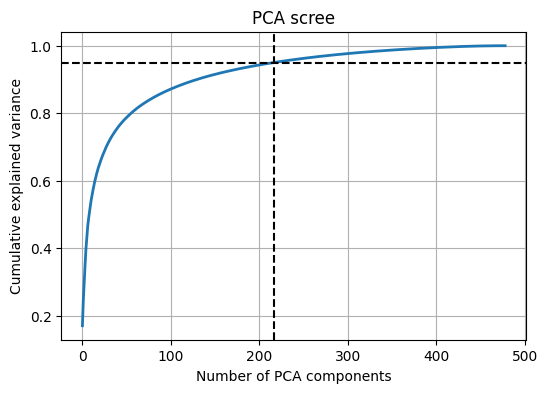

In [11]:
plt.figure(figsize=(6,4))
plt.plot(cumvar, lw=2)
plt.axhline(thresh, color='k', ls='--')
plt.axvline(n95,   color='k', ls='--')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA scree')
plt.grid(True)
plt.show()

### Neural

#### Finding how many dims the spikes live in

In [12]:
T = 479 # total time in seconds
N = len(spk) # number of neurons

In [13]:
spiketrains = []
for n in range(N):
    st = neo.SpikeTrain(
        times=spk[n] * pq.s,
        t_start=0*pq.s,
        t_stop=T*pq.s
    )
    spiketrains.append(st)

In [14]:
# Folding for cross-validation
trials = []
for start in [0, 160, 320]:
    t0 = start   * pq.s
    t1 = (start + 160) * pq.s
    trials.append([st.time_slice(t0, t1) for st in spiketrains])

x_dims = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
log_likelihoods = []
for x_dim in x_dims:
    gpfa_cv = GPFA(bin_size=1*pq.s, x_dim=x_dim)
    cv_log_likelihoods = cross_val_score(gpfa_cv, trials, cv=3, n_jobs=1, verbose=True)
    log_likelihoods.append(np.mean(cv_log_likelihoods))

Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 40 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 50 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 110 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 45 EM iterations.)


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished


Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 155 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 80 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 55 EM iterations.)


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.7s finished


Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 60 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 110 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...


...

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    8.6s finished


Initializing parameters using factor analysis...

Fitting GPFA model...
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 175 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 405 EM iterations.)


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    8.5s finished


Initializing parameters using factor analysis...

Fitting GPFA model...
Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 175 EM iterations.)
Initializing parameters using factor analysis...

Fitting GPFA model...


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   10.5s finished


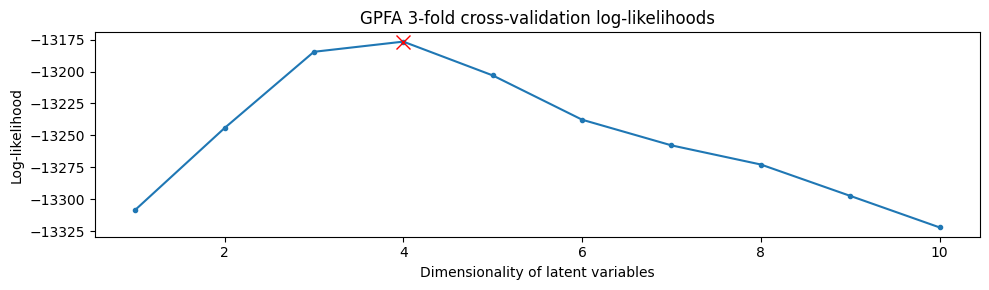

In [15]:
f = plt.figure(figsize=(10, 3))
plt.xlabel('Dimensionality of latent variables')
plt.ylabel('Log-likelihood')
plt.title('GPFA 3-fold cross-validation log-likelihoods')
plt.plot(x_dims, log_likelihoods, '.-')
plt.plot(x_dims[np.argmax(log_likelihoods)], np.max(log_likelihoods), 'x', markersize=10, color='r')
plt.tight_layout()
plt.show()

#### Now that we know spikes are 4d, full reduction

In [16]:
gpfa_best = GPFA(bin_size=1*pq.s, x_dim=4)
y = gpfa_best.fit_transform([spiketrains], returned_data=["latent_variable_orth", "latent_variable"])

Initializing parameters using factor analysis...

Fitting GPFA model...
Fitting has converged after 80 EM iterations.)


In [17]:
y["latent_variable_orth"][0]

array([[ 1.68952374,  2.3027431 ,  1.87955301, ...,  0.00636761,
        -0.79042387,  0.41591178],
       [-0.95634686, -2.74727234, -2.12148104, ...,  0.38778092,
         0.46151863, -0.7830314 ],
       [ 0.44356241, -1.82161231, -1.08294435, ..., -0.78332598,
        -1.44249179, -0.04670998],
       [ 1.66192163,  2.12218401,  0.85118337, ...,  0.06453367,
        -0.37214873, -0.60780977]])

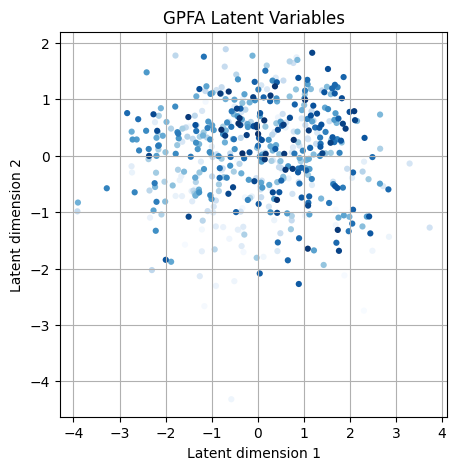

In [18]:
a, b, c, d = y["latent_variable_orth"][0]

plt.figure(figsize=(5, 5))
# colors from red to blue
cmap = sns.color_palette("Blues", as_cmap=True)
plt.scatter(a, b, c=np.arange(len(a)), cmap=cmap, s=20, edgecolor='none')
plt.xlabel('Latent dimension 1')
plt.ylabel('Latent dimension 2')
plt.title('GPFA Latent Variables')
plt.grid()
plt.show()

# Decoding

In [19]:
Y = y["latent_variable_orth"][0].T
Y.shape

(479, 4)

In [20]:
S_pca.shape

(479, 479)

In [21]:
tscv   = TimeSeriesSplit(n_splits=4)                # 4 contiguous folds
alphas = np.logspace(-3, 3, 7)                      # ridge penalty gri

In [22]:
ks    = np.arange(1, S_pca.shape[1]+1)
mean_r2 = np.zeros_like(ks, dtype=float)

In [34]:
for i, k in tqdm(enumerate(ks), total=len(ks), desc='Fitting models'):
    Xk = S_pca[:, :k]   # only first k PCA dims

    r2_folds = []
    for train_idx, test_idx in tscv.split(Xk):
        X_tr, X_te = Xk[train_idx], Xk[test_idx]
        Y_tr, Y_te = Y[train_idx],  Y[test_idx]

        # multi-output ridge: fits one regressor per latent dim under the hood
        model = RidgeCV(alphas=alphas, cv=3)
        model.fit(X_tr, Y_tr)

        Y_pred = model.predict(X_te)
        # average R² across the M latent dims
        r2_folds.append(r2_score(Y_te, Y_pred, multioutput='uniform_average'))

    mean_r2[i] = np.mean(r2_folds)



Fitting models: 100%|██████████| 479/479 [00:28<00:00, 16.60it/s]


→ You only need k = 1 PCs to reach 95% of peak R²


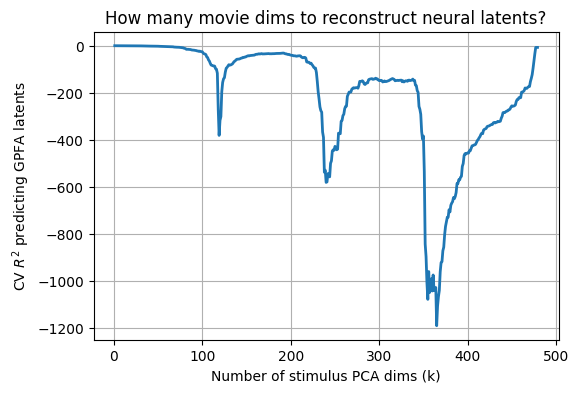

In [36]:
# ── 3) PLOT & READ OFF “BRAIN” COMPRESSION ─────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(ks, mean_r2, lw=2)
plt.xlabel('Number of stimulus PCA dims (k)')
plt.ylabel('CV $R^2$ predicting GPFA latents')
plt.title('How many movie dims to reconstruct neural latents?')
plt.grid(True)

# best = mean_r2.max()
# plt.axhline(best * 0.95, color='k', ls='--',
#             label=f'95% of peak ($R^2$={best:.2f})')
# plt.legend(loc='lower right')
# plt.show()

k95 = ks[np.argmax(mean_r2 >= best * 0.95)]
print(f"→ You only need k = {k95} PCs to reach 95% of peak R²")